In [18]:
  import pandas as pd
  import numpy as np

In [19]:
def load_data():
    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    # now we split this into data and target
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target = raw_df.values[1::2, 2]
    # These are the Feature names based on the original dataset
    feature_names = [
        'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
        'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
    ]
    # Create a DataFrame
    df = pd.DataFrame(data, columns=feature_names)
    df['MEDV'] = target # here MEDV is our target variable
    return df

In [20]:
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Added numpy import here

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
# Define paths for saving models and reports
MODEL_DIR = 'models'
REPORT_DIR = 'reports'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

In [33]:
def preprocess_data(df):
    """
    Performs feature-target split, trains-test split, and defines preprocessing steps.
    """
    X = df.drop('MEDV', axis=1)
    y = df['MEDV']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Create a preprocessing pipeline
    # Note: Outlier capping before scaling is usually preferred to avoid
    # scaling skewing the outlier detection.
    preprocessor = Pipeline([
        ('outlier_capper', IQROutlierCapper()),
        ('scaler', StandardScaler())
    ])

    return X_train, X_test, y_train, y_test, preprocessor

In [30]:
# BaseEstimator and TransformerMixin for custom transformer
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np # Import numpy here for the class

# Define a custom transformer for outlier capping using IQR
class IQROutlierCapper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.lower_bounds = {}
        self.upper_bounds = {}
        for col in X.columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            self.lower_bounds[col] = Q1 - 1.5 * IQR
            self.upper_bounds[col] = Q3 + 1.5 * IQR
        return self

    def transform(self, X, y=None):
        X_capped = X.copy()
        for col in X.columns:
            X_capped[col] = np.where(X_capped[col] < self.lower_bounds[col], self.lower_bounds[col], X_capped[col])
            X_capped[col] = np.where(X_capped[col] > self.upper_bounds[col], self.upper_bounds[col], X_capped[col])
        return X_capped

In [24]:
def train_models(X_train, y_train, preprocessor):
    """
    Trains various classical ML models with basic hyperparameter tuning using GridSearchCV.
    Returns a dictionary of trained models and their best scores.
    """
    models = {
        'LinearRegression': LinearRegression(),
        'Ridge': Ridge(),
        'Lasso': Lasso(),
        'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
        'RandomForestRegressor': RandomForestRegressor(random_state=42),
        'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42),
        'SVR': SVR()
    }

    # Define parameter grids for each model (simplified for demonstration)
    param_grids = {
        'LinearRegression': {}, # No params to tune for basic LR
        'Ridge': {'ridge__alpha': [0.1, 1.0, 10.0]},
        'Lasso': {'lasso__alpha': [0.1, 1.0, 10.0]},
        'DecisionTreeRegressor': {'decisiontreeregressor__max_depth': [None, 5, 10, 20]},
        'RandomForestRegressor': {'randomforestregressor__n_estimators': [50, 100, 200],
                                  'randomforestregressor__max_depth': [None, 10]},
        'GradientBoostingRegressor': {'gradientboostingregressor__n_estimators': [50, 100, 200],
                                      'gradientboostingregressor__learning_rate': [0.01, 0.1, 0.2]},
        'SVR': {'svr__C': [0.1, 1, 10], 'svr__gamma': ['scale', 'auto']}
    }

    trained_models = {}
    best_scores = {}

    print("\n--- Training Models with Cross-Validation and Hyperparameter Tuning ---")
    for name, model in models.items():
        print(f"\nTraining {name}...")
        # Create a pipeline for each model including preprocessing
        full_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            (name.lower(), model) # The model step is named after the model class in lowercase
        ])

        # GridSearchCV for hyperparameter tuning with cross-validation
        # Using neg_mean_squared_error because GridSearchCV maximizes score, so we minimize negative MSE.
        grid_search = GridSearchCV(full_pipeline, param_grids[name], cv=5,
                                   scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
        grid_search.fit(X_train, y_train)

        trained_models[name] = grid_search.best_estimator_
        best_scores[name] = -grid_search.best_score_ # Convert back to positive MSE
        print(f"Best parameters for {name}: {grid_search.best_params_}")
        print(f"Best CV MSE for {name}: {best_scores[name]:.4f}")

    return trained_models, best_scores

In [25]:
# --- 4. Model Evaluation ---

def evaluate_models(trained_models, X_test, y_test):
    """
    Evaluates trained models on the test set.
    Returns a dictionary of evaluation metrics for each model.
    """
    evaluation_results = {}
    print("\n--- Evaluating Models on Test Set ---")
    for name, model in trained_models.items():
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        evaluation_results[name] = {
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        }
        print(f"\n{name} Test Metrics:")
        print(f"  MAE: {mae:.4f}")
        print(f"  MSE: {mse:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  R2: {r2:.4f}")

    return evaluation_results

In [26]:
# --- 5. Model Selection and Persistence ---

def select_and_save_best_model(evaluation_results, trained_models, metric='RMSE'):
    """
    Selects the best model based on the specified metric and saves it.
    """
    if metric not in ['MAE', 'MSE', 'RMSE', 'R2']:
        raise ValueError("Invalid metric. Choose from 'MAE', 'MSE', 'RMSE', 'R2'.")

    best_model_name = None
    best_metric_value = float('inf') if metric in ['MAE', 'MSE', 'RMSE'] else -float('inf')

    print(f"\n--- Selecting Best Model based on {metric} ---")
    for name, metrics in evaluation_results.items():
        current_metric_value = metrics[metric]
        if metric in ['MAE', 'MSE', 'RMSE']: # Lower is better
            if current_metric_value < best_metric_value:
                best_metric_value = current_metric_value
                best_model_name = name
        else: # R2, Higher is better
            if current_metric_value > best_metric_value:
                best_metric_value = current_metric_value
                best_model_name = name

    print(f"Best Model: {best_model_name} with {metric}: {best_metric_value:.4f}")

    best_model_pipeline = trained_models[best_model_name]
    model_filename = os.path.join(MODEL_DIR, f'best_house_price_model_{best_model_name.lower()}.pkl')
    joblib.dump(best_model_pipeline, model_filename)
    print(f"Best model saved to: {model_filename}")

    # Save evaluation results to a CSV for reporting
    results_df = pd.DataFrame.from_dict(evaluation_results, orient='index')
    results_filepath = os.path.join(REPORT_DIR, 'model_evaluation_results.csv')
    results_df.to_csv(results_filepath, index_label='Model')
    print(f"Evaluation results saved to: {results_filepath}")

    return best_model_pipeline, model_filename

In [27]:
# --- 6. Prediction Function (for later use) ---

def predict_house_price(model_path, new_data):
    """
    Loads a saved model and makes predictions on new data.
    new_data: A pandas DataFrame with the same features as the training data.
    """
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found at: {model_path}")

    loaded_model = joblib.load(model_path)
    print(f"Model loaded from: {model_path}")

    # The loaded model is a pipeline that handles preprocessing automatically
    predictions = loaded_model.predict(new_data)
    return predictions

In [28]:
# --- Main Workflow Orchestrator ---

def run_ml_workflow():
    """
    Orchestrates the complete machine learning workflow.
    """
    print("--- Starting Machine Learning Workflow ---")

    # 1. Data Ingestion
    df = load_data()
    print(f"\nRaw data loaded. Shape: {df.shape}")
    print("First 5 rows:\n", df.head())

    # 2. Data Preprocessing
    X_train, X_test, y_train, y_test, preprocessor = preprocess_data(df)
    print(f"\nData split and preprocessor defined. Train size: {X_train.shape}, Test size: {X_test.shape}")

    # 3. Model Training
    trained_models, best_cv_scores = train_models(X_train, y_train, preprocessor)

    # 4. Model Evaluation
    evaluation_results = evaluate_models(trained_models, X_test, y_test)

    # 5. Model Selection and Persistence
    best_model, model_path = select_and_save_best_model(evaluation_results, trained_models, metric='RMSE')

    print("\n--- Workflow Complete ---")
    print(f"You can now use the model at '{model_path}' for predictions.")

    # --- Example of using the prediction function ---
    print("\n--- Demonstrating Prediction Function ---")
    # Create some dummy new data (ensure it has the same columns as the original features)
    # For a real scenario, this would come from a new data source
    dummy_new_data = pd.DataFrame(X_test.iloc[0:5]) # Take first 5 test samples as new data
    dummy_new_data.index = range(len(dummy_new_data)) # Reset index for clean display

    print("\nDummy new data for prediction (first 5 test samples):")
    print(dummy_new_data)

    predicted_prices = predict_house_price(model_path, dummy_new_data)
    print("\nPredicted House Prices for dummy data:")
    for i, price in enumerate(predicted_prices):
        print(f"Sample {i+1}: ${price*1000:.2f}") # Convert back to original scale if needed for interpretation

    # Optional: Plotting R2 scores for comparison
    r2_scores = {name: res['R2'] for name, res in evaluation_results.items()}
    models = list(r2_scores.keys())
    scores = list(r2_scores.values())

    plt.figure(figsize=(12, 6))
    sns.barplot(x=models, y=scores, palette='viridis')
    plt.ylabel('R-squared Score')
    plt.title('R-squared Scores of Different Models on Test Set')
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(REPORT_DIR, 'model_r2_scores.png'))
    plt.show()
    print(f"R-squared scores plot saved to: {os.path.join(REPORT_DIR, 'model_r2_scores.png')}")

--- Starting Machine Learning Workflow ---

Raw data loaded. Shape: (506, 14)
First 5 rows:
       CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

Data split and preprocessor defined. Train size: (404, 13), Test size: (102, 13)

--- Training Models with Cross-Validation and Hyperparameter Tuning ---

Training LinearRegression...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters for 

/tmp/ipython-input-28-3444712387.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette='viridis')


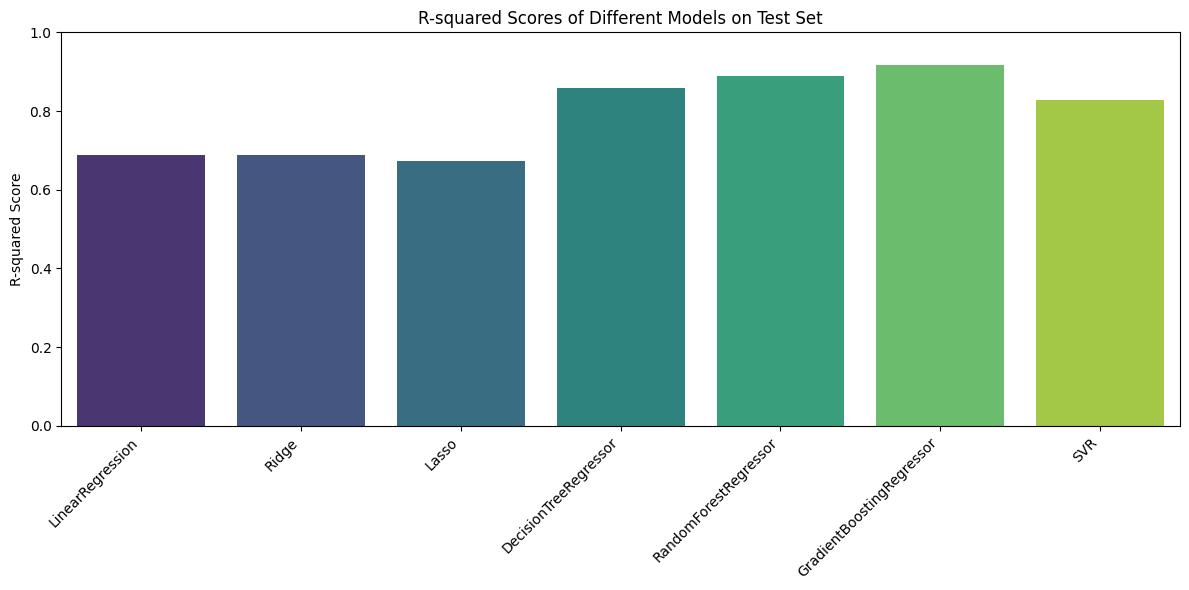

R-squared scores plot saved to: reports/model_r2_scores.png


In [35]:
# --- Run the workflow ---
if __name__ == "__main__":
    run_ml_workflow()